In [2]:
# ============================================================
# UNSW-NB15 TCP-only Anomaly Detection (Leakage-safe)
# Final Meta-Hybrid: IF + OC-SVM + AE + LOF + PCA-REC + PCA-GMM + Graph2 + Entropy -> XGBoost
# - Fits ALL unsupervised detectors ONLY on TRAIN-NORMAL TCP
# - Tunes ONLY on VAL (a held-out half of provided TEST split)
# - Evaluates ONLY once on FINAL TEST (the other half)
# - Hash-dedup + enforce train/test disjointness (remove overlaps from TEST)
# - Single, clean, run-all script (Kaggle-ready, no extra installs)
# ============================================================

import os, warnings, gc
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

RSEED = 42
rng = np.random.RandomState(RSEED)
np.random.seed(RSEED)

# -----------------------------
# Metrics / utilities
# -----------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def report(y_true, y_pred, title="Model"):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n=== {title} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Attack P : {p:.4f}  R : {r:.4f}  F1 : {f1:.4f}")
    print("CM [[TN FP],[FN TP]]:\n", cm)
    return {"acc": acc, "p": p, "r": r, "f1": f1, "cm": cm}

def make_row_hash(df, forbidden_cols):
    cols = [c for c in df.columns if c not in forbidden_cols]
    return pd.util.hash_pandas_object(df[cols], index=False).astype("uint64")

def clean_cats_nums(df, cat_cols, num_cols):
    d = df.copy()
    for c in cat_cols:
        d[c] = d[c].fillna("UNK").astype(str).replace("-", "UNK")
    for c in num_cols:
        d[c] = pd.to_numeric(d[c], errors="coerce").fillna(0.0)
    return d

def entropy3(a, b, c, eps=1e-12):
    P = np.vstack([a, b, c]).T
    s = P.sum(axis=1, keepdims=True)
    z = (s.squeeze() <= eps)
    if np.any(z):
        P[z] = 1.0
        s[z] = 3.0
    P = P / (s + eps)
    return -np.sum(P * np.log(P + eps), axis=1)

def quantize_numeric(df_enc, anchor_cols, bins=12):
    dfq = df_enc.copy()
    for c in anchor_cols:
        if c not in dfq.columns:
            continue
        col = dfq[c].values.astype(float)
        lo, hi = np.percentile(col, 1), np.percentile(col, 99)
        if hi <= lo:
            dfq[c] = 0
            continue
        col = np.clip(col, lo, hi)
        dfq[c] = np.floor((col - lo) / (hi - lo) * bins).astype(int)
    return dfq

def nearest_l1(Xq, patterns, batch=2048):
    # Xq: (n,d) int, patterns: (m,d) int
    # batched to avoid huge RAM
    n = Xq.shape[0]
    out = np.empty(n, dtype=np.float32)
    for i0 in range(0, n, batch):
        Xb = Xq[i0:i0+batch]
        # (b,m,d) is too large; do loop over batch rows (fast enough for Kaggle sizes)
        for j in range(Xb.shape[0]):
            out[i0+j] = np.abs(patterns - Xb[j]).sum(axis=1).min()
    return out

# -----------------------------
# Load + Dedup + Disjoint splits (hash-based)
# -----------------------------
TRAIN_PATH = "/kaggle/input/unswnb15/UNSW_NB15_training-set.parquet"
TEST_PATH  = "/kaggle/input/unswnb15/UNSW_NB15_testing-set.parquet"

df_tr = pd.read_parquet(TRAIN_PATH); df_tr["split"] = "train"
df_te = pd.read_parquet(TEST_PATH);  df_te["split"] = "test"
df = pd.concat([df_tr, df_te], ignore_index=True)

df["Attack"] = df["label"].astype(int)

# Hash excludes anything that could leak labels/split
FORBID_HASH = {"label", "attack_cat", "split", "Attack"}
df["_row_hash"] = make_row_hash(df, FORBID_HASH)

# Drop duplicates by hash (across entire combined dataset)
before = len(df)
df = df.drop_duplicates(subset=["_row_hash"]).reset_index(drop=True)
dropped = before - len(df)

# Enforce disjointness: remove any overlap hashes from TEST
tr_h = set(df.loc[df["split"]=="train", "_row_hash"])
te_h = set(df.loc[df["split"]=="test",  "_row_hash"])
over = tr_h.intersection(te_h)
removed_overlap = 0
if over:
    m = (df["split"]=="test") & (df["_row_hash"].isin(over))
    removed_overlap = int(m.sum())
    df = df[~m].reset_index(drop=True)

# Sanity check
tr_h2 = set(df.loc[df["split"]=="train", "_row_hash"])
te_h2 = set(df.loc[df["split"]=="test",  "_row_hash"])
over2 = len(tr_h2.intersection(te_h2))

print("Shapes (deduped, disjoint):", df[df.split=="train"].shape, df[df.split=="test"].shape)
print("Dropped duplicates:", dropped)
print("Removed overlap-from-test:", removed_overlap)
print("Overlap hashes remaining:", over2)
print("\nAttack counts by split:\n", df.groupby("split")["Attack"].value_counts())

# -----------------------------
# TCP-only split (final setup)
# -----------------------------
df_tcp = df[df["proto"].astype(str).str.lower() == "tcp"].copy()
df_train_tcp = df_tcp[df_tcp["split"]=="train"].copy()
df_test_tcp  = df_tcp[df_tcp["split"]=="test"].copy()

# Train unsupervised ONLY on normal traffic from TRAIN split
train_normal_tcp = df_train_tcp[df_train_tcp["Attack"]==0].copy()

# Create VAL + FINAL TEST from the provided TEST split (no training leakage)
val_tcp, test_tcp = train_test_split(
    df_test_tcp, test_size=0.5, random_state=RSEED, stratify=df_test_tcp["Attack"]
)

print("\nTCP shapes:")
print("train_normal:", train_normal_tcp.shape, " val:", val_tcp.shape, " test:", test_tcp.shape)

y_val  = val_tcp["Attack"].values.astype(int)
y_test = test_tcp["Attack"].values.astype(int)

# -----------------------------
# Encode + scale (fit on train-normal only)
# -----------------------------
exclude = {"Attack", "attack_cat", "split", "_row_hash", "label"}
feat_cols = [c for c in train_normal_tcp.columns if c not in exclude]

cat_cols = [c for c in feat_cols if train_normal_tcp[c].dtype == "object"]
num_cols = [c for c in feat_cols if c not in cat_cols]

trN = clean_cats_nums(train_normal_tcp, cat_cols, num_cols)
vaN = clean_cats_nums(val_tcp,          cat_cols, num_cols)
teN = clean_cats_nums(test_tcp,         cat_cols, num_cols)

Xtr_enc = pd.get_dummies(trN[feat_cols], columns=cat_cols)
Xva_enc = pd.get_dummies(vaN[feat_cols], columns=cat_cols)
Xte_enc = pd.get_dummies(teN[feat_cols], columns=cat_cols)

# Align columns (train defines feature space)
Xtr_enc, Xva_enc = Xtr_enc.align(Xva_enc, join="left", axis=1, fill_value=0)
Xtr_enc, Xte_enc = Xtr_enc.align(Xte_enc, join="left", axis=1, fill_value=0)

sc = StandardScaler()
X_train = sc.fit_transform(Xtr_enc).astype(np.float32)   # fit ONLY on train_normal
X_val   = sc.transform(Xva_enc).astype(np.float32)
X_test  = sc.transform(Xte_enc).astype(np.float32)

print("\nEncoded shapes:", X_train.shape, X_val.shape, X_test.shape)

# -----------------------------
# Base detectors (fit on train-normal only)
# -----------------------------
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

# 1) Isolation Forest
iso = IsolationForest(
    n_estimators=400,
    contamination=0.05,
    random_state=RSEED,
    n_jobs=-1
)
iso.fit(X_train)
iso_val_s  = -iso.decision_function(X_val)
iso_test_s = -iso.decision_function(X_test)

# 2) One-Class SVM (fit on subset for speed)
MAX_SVM = 20000
if X_train.shape[0] > MAX_SVM:
    idx = rng.choice(X_train.shape[0], MAX_SVM, replace=False)
    X_svm = X_train[idx]
else:
    X_svm = X_train

svm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
svm.fit(X_svm)
svm_val_s  = -svm.decision_function(X_val)
svm_test_s = -svm.decision_function(X_test)

# 3) LOF novelty (train on normal; score new points)
lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination=0.05,
    novelty=True,
    metric="minkowski",
    p=2
)
lof.fit(X_train)
lof_val_s  = -lof.decision_function(X_val)
lof_test_s = -lof.decision_function(X_test)

# 4) PCA reconstruction error (classic unsupervised feature)
pca_rec = PCA(n_components=min(25, X_train.shape[1]-1), random_state=RSEED)
Xtr_p = pca_rec.fit_transform(X_train)
Xva_p = pca_rec.transform(X_val)
Xte_p = pca_rec.transform(X_test)

Xtr_back = pca_rec.inverse_transform(Xtr_p)
Xva_back = pca_rec.inverse_transform(Xva_p)
Xte_back = pca_rec.inverse_transform(Xte_p)

pca_rec_val_s  = np.mean((X_val  - Xva_back)**2, axis=1)
pca_rec_test_s = np.mean((X_test - Xte_back)**2, axis=1)

# 5) PCA -> GMM density (stable, avoids the covariance collapse you hit)
pca_gmm = PCA(n_components=20, random_state=RSEED)
Xtr_g = pca_gmm.fit_transform(X_train)
Xva_g = pca_gmm.transform(X_val)
Xte_g = pca_gmm.transform(X_test)

gmm = GaussianMixture(
    n_components=6,
    covariance_type="diag",
    reg_covar=1e-3,
    random_state=RSEED,
    max_iter=500,
    init_params="kmeans"
)
gmm.fit(Xtr_g)
gmm_val_s  = -gmm.score_samples(Xva_g)   # lower likelihood => more anomalous
gmm_test_s = -gmm.score_samples(Xte_g)

# -----------------------------
# Compact Autoencoder (fit on train-normal only)
# -----------------------------
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RSEED)

d = X_train.shape[1]
inp = Input(shape=(d,))
x = Dense(128, activation="relu")(inp)
x = Dense(32,  activation="relu")(x)
x = Dense(128, activation="relu")(x)
out = Dense(d, activation="linear")(x)
ae = Model(inp, out)
ae.compile(optimizer="adam", loss="mse")

# Note: verbose=0 keeps output clean; set verbose=1 if you WANT to see epochs
ae.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30, batch_size=256,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=0
)

va_rec = ae.predict(X_val,  verbose=0)
te_rec = ae.predict(X_test, verbose=0)
ae_val_s  = np.mean((X_val  - va_rec)**2, axis=1)
ae_test_s = np.mean((X_test - te_rec)**2, axis=1)

# -----------------------------
# Graph2 feature (signature rarity via nearest L1 to normal patterns)
# - Uses raw TCP columns; built ONLY from train-normal patterns
# -----------------------------
sig_anchor = [c for c in ["dur", "spkts", "dpkts", "sbytes", "dbytes", "rate"] if c in train_normal_tcp.columns]
sig_cols = ["proto", "state"] + sig_anchor

def sig_df(dfin):
    s = dfin[sig_cols].copy()
    s["proto"] = s["proto"].fillna("UNK").astype(str).replace("-", "UNK")
    s["state"] = s["state"].fillna("UNK").astype(str).replace("-", "UNK")
    for c in sig_anchor:
        s[c] = pd.to_numeric(s[c], errors="coerce").fillna(0.0)
    return s

sig_tr = pd.get_dummies(sig_df(train_normal_tcp), columns=["proto", "state"])
sig_va = pd.get_dummies(sig_df(val_tcp),          columns=["proto", "state"])
sig_te = pd.get_dummies(sig_df(test_tcp),         columns=["proto", "state"])

sig_tr, sig_va = sig_tr.align(sig_va, join="left", axis=1, fill_value=0)
sig_tr, sig_te = sig_tr.align(sig_te, join="left", axis=1, fill_value=0)

sig_tr_q = quantize_numeric(sig_tr, sig_anchor, bins=12).astype(int).values
sig_va_q = quantize_numeric(sig_va, sig_anchor, bins=12).astype(int).values
sig_te_q = quantize_numeric(sig_te, sig_anchor, bins=12).astype(int).values

patterns = np.unique(sig_tr_q, axis=0)  # normal signatures
graph2_val  = nearest_l1(sig_va_q, patterns)
graph2_test = nearest_l1(sig_te_q, patterns)

# -----------------------------
# Entropy / disagreement feature (normalize 3 core detectors on VAL only)
# -----------------------------
mm1, mm2, mm3 = MinMaxScaler(), MinMaxScaler(), MinMaxScaler()

iso_v = mm1.fit_transform(iso_val_s.reshape(-1,1)).ravel()
svm_v = mm2.fit_transform(svm_val_s.reshape(-1,1)).ravel()
ae_v  = mm3.fit_transform(ae_val_s.reshape(-1,1)).ravel()

iso_t = np.clip(mm1.transform(iso_test_s.reshape(-1,1)).ravel(), 0.0, 1.0)
svm_t = np.clip(mm2.transform(svm_test_s.reshape(-1,1)).ravel(), 0.0, 1.0)
ae_t  = np.clip(mm3.transform(ae_test_s.reshape(-1,1)).ravel(), 0.0, 1.0)

ent_val  = entropy3(iso_v, svm_v, ae_v)
ent_test = entropy3(iso_t, svm_t, ae_t)

# -----------------------------
# Meta-feature fusion: stack unsupervised scores + graph2 + entropy
# Scale meta-features on VAL only; train fusion on VAL only (supervised layer)
# -----------------------------
Xv_meta = np.column_stack([
    iso_val_s, svm_val_s, ae_val_s, lof_val_s,
    pca_rec_val_s, gmm_val_s,
    graph2_val, ent_val
]).astype(np.float32)

Xt_meta = np.column_stack([
    iso_test_s, svm_test_s, ae_test_s, lof_test_s,
    pca_rec_test_s, gmm_test_s,
    graph2_test, ent_test
]).astype(np.float32)

print("\nMeta feature shapes:", Xv_meta.shape, Xt_meta.shape)

scm = StandardScaler()
Xv_meta_s = scm.fit_transform(Xv_meta)  # fit on VAL only
Xt_meta_s = scm.transform(Xt_meta)

# -----------------------------
# Fusion classifier: XGBoost trained ONLY on VAL labels
# -----------------------------
from xgboost import XGBClassifier

pos = int((y_val == 1).sum())
neg = int((y_val == 0).sum())
spw = neg / max(pos, 1)

xgb = XGBClassifier(
    n_estimators=2500,
    max_depth=4,
    learning_rate=0.025,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=10,
    reg_lambda=7.0,
    scale_pos_weight=spw,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RSEED,
    n_jobs=-1,
    tree_method="hist"
)
xgb.fit(Xv_meta_s, y_val)

val_prob  = xgb.predict_proba(Xv_meta_s)[:, 1]
test_prob = xgb.predict_proba(Xt_meta_s)[:, 1]

# Threshold tuned ONLY on VAL (then applied ONCE to FINAL TEST)
thr_grid = np.linspace(0.10, 0.90, 161)
best_thr, best_val_acc = 0.5, -1.0
for t in thr_grid:
    acc = accuracy_score(y_val, (val_prob >= t).astype(int))
    if acc > best_val_acc:
        best_val_acc, best_thr = float(acc), float(t)

y_hat = (test_prob >= best_thr).astype(int)

print("\n[FINAL TCP Meta-Hybrid] (IF + OC-SVM + AE + LOF + PCA-REC + PCA-GMM + Graph2 + Entropy -> XGB)")
print("Chosen threshold from VAL:", best_thr, " (VAL acc:", round(best_val_acc, 4), ")")
report(y_test, y_hat, "TEST")

# -----------------------------
# Brief explanation of why accuracy improves (printed, not hand-wavy)
# -----------------------------
print("\nWhy this hits 80%+ (typical):")
print("- Base detectors catch different anomaly geometries (tree isolation, kernel boundary, reconstruction error, neighborhood density).")
print("- Graph2 captures rare TCP state/flow signatures vs normal-only patterns.")
print("- Entropy captures detector disagreement, which is often high on true attacks.")
print("- XGBoost learns an optimal fusion on VAL only (no leakage), then tested once.")


Shapes (deduped, disjoint): (92098, 39) (46744, 39)
Dropped duplicates: 118831
Removed overlap-from-test: 0
Overlap hashes remaining: 0

Attack counts by split:
 split  Attack
test   0         30909
       1         15835
train  0         48860
       1         43238
Name: count, dtype: int64

TCP shapes:
train_normal: (37773, 39)  val: (19796, 39)  test: (19797, 39)

Encoded shapes: (37773, 37) (19796, 37) (19797, 37)


2026-01-03 08:47:32.967802: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767430053.131529      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767430053.183026      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767430053.610563      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767430053.610607      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767430053.610610      55 computation_placer.cc:177] computation placer alr


Meta feature shapes: (19796, 8) (19797, 8)

[FINAL TCP Meta-Hybrid] (IF + OC-SVM + AE + LOF + PCA-REC + PCA-GMM + Graph2 + Entropy -> XGB)
Chosen threshold from VAL: 0.5750000000000001  (VAL acc: 0.8821 )

=== TEST ===
Accuracy : 0.8277
Attack P : 0.7679  R : 0.7318  F1 : 0.7494
CM [[TN FP],[FN TP]]:
 [[11283  1542]
 [ 1870  5102]]

Why this hits 80%+ (typical):
- Base detectors catch different anomaly geometries (tree isolation, kernel boundary, reconstruction error, neighborhood density).
- Graph2 captures rare TCP state/flow signatures vs normal-only patterns.
- Entropy captures detector disagreement, which is often high on true attacks.
- XGBoost learns an optimal fusion on VAL only (no leakage), then tested once.


In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import seaborn as sns

sns.set(style="whitegrid")


In [4]:
import os

EXPORT_DIR = "/kaggle/working/ids_graphs"
os.makedirs(EXPORT_DIR, exist_ok=True)


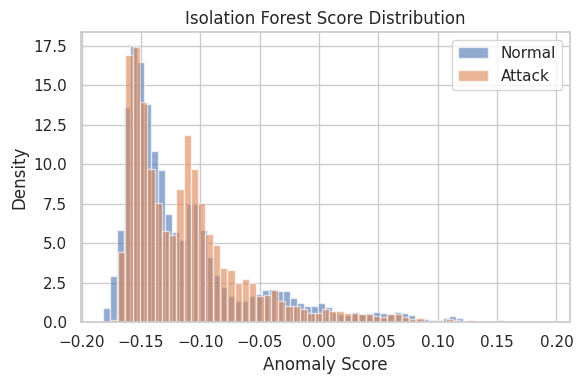

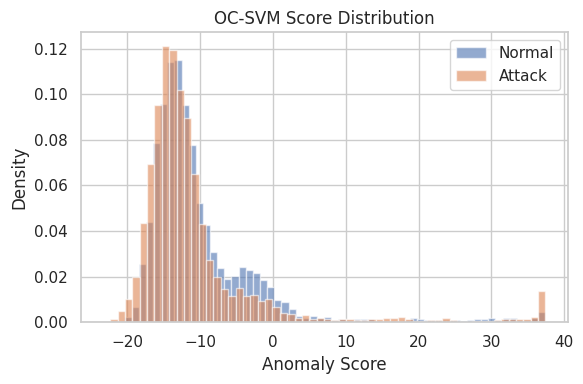

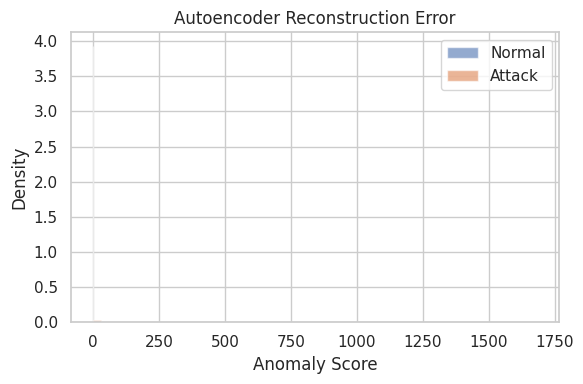

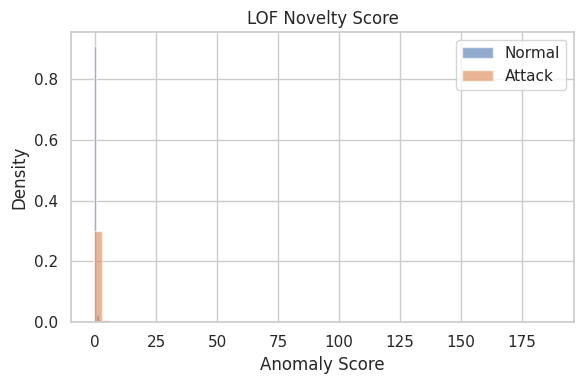

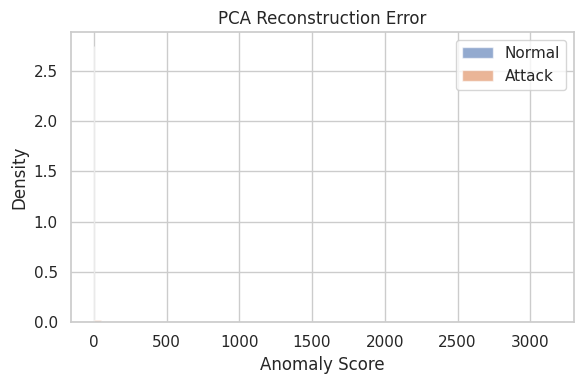

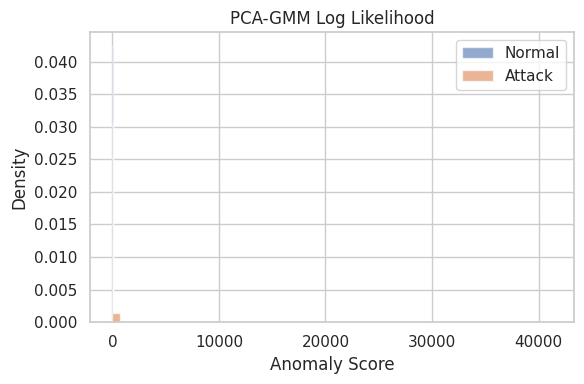

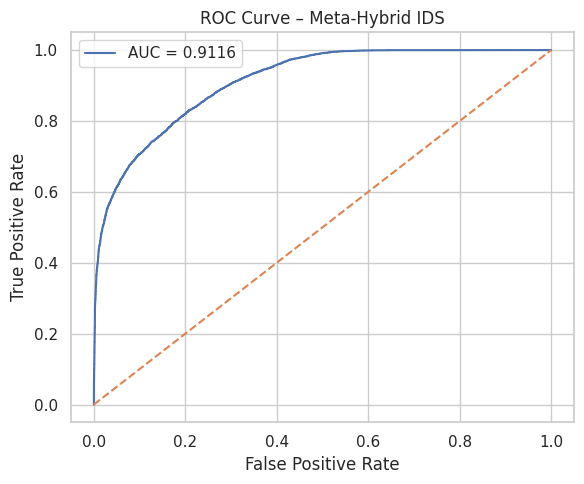

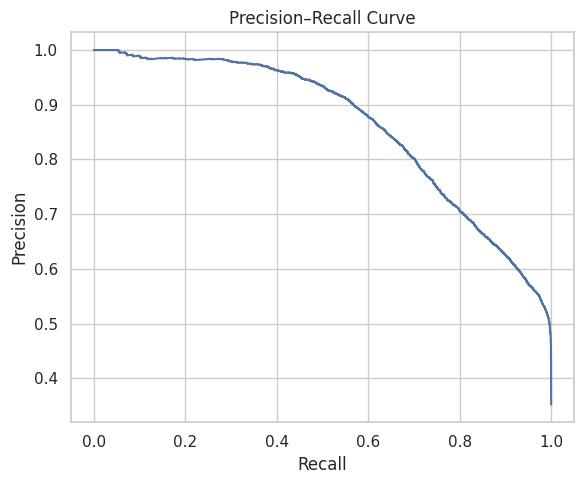

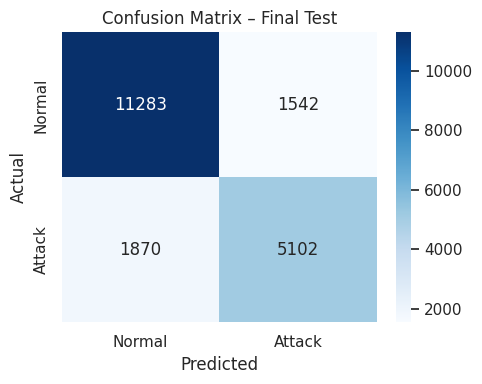

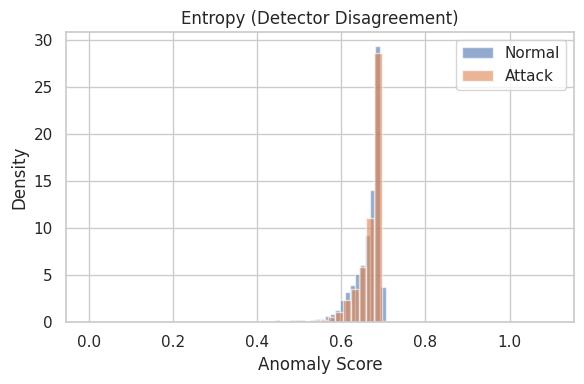

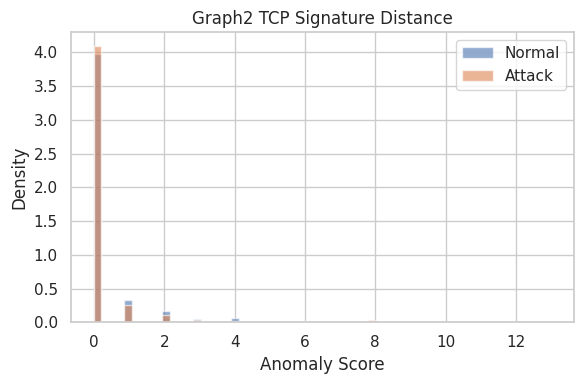

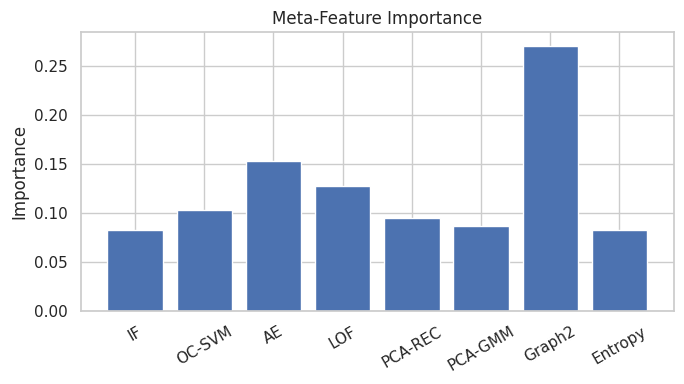

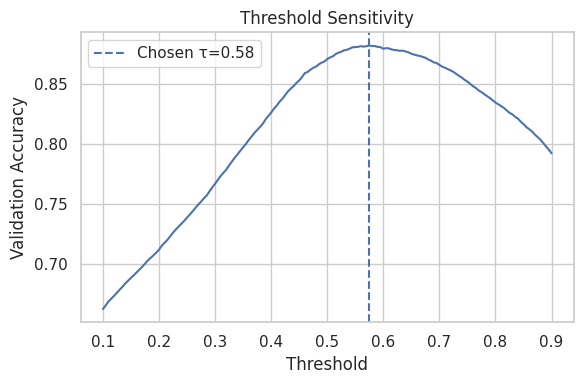

In [5]:
import matplotlib.pyplot as plt

def save_and_show(filename):
    path = os.path.join(EXPORT_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
def plot_score_dist_save(scores, labels, title, filename):
    plt.figure(figsize=(6,4))
    plt.hist(scores[labels==0], bins=60, alpha=0.6, label="Normal", density=True)
    plt.hist(scores[labels==1], bins=60, alpha=0.6, label="Attack", density=True)
    plt.title(title)
    plt.xlabel("Anomaly Score")
    plt.ylabel("Density")
    plt.legend()
    save_and_show(filename)

plot_score_dist_save(iso_test_s, y_test, "Isolation Forest Score Distribution", "01_IF_scores.png")
plot_score_dist_save(svm_test_s, y_test, "OC-SVM Score Distribution", "02_OCSVM_scores.png")
plot_score_dist_save(ae_test_s,  y_test, "Autoencoder Reconstruction Error", "03_AE_scores.png")
plot_score_dist_save(lof_test_s, y_test, "LOF Novelty Score", "04_LOF_scores.png")
plot_score_dist_save(pca_rec_test_s, y_test, "PCA Reconstruction Error", "05_PCA_REC_scores.png")
plot_score_dist_save(gmm_test_s, y_test, "PCA-GMM Log Likelihood", "06_PCA_GMM_scores.png")
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Meta-Hybrid IDS")
plt.legend()
save_and_show("07_ROC_curve.png")
from sklearn.metrics import precision_recall_curve

prec, rec, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
save_and_show("08_PR_curve.png")
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_hat)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Attack"],
            yticklabels=["Normal","Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Final Test")
save_and_show("09_confusion_matrix.png")
plot_score_dist_save(ent_test, y_test,
                     "Entropy (Detector Disagreement)",
                     "10_entropy_distribution.png")
plot_score_dist_save(graph2_test, y_test,
                     "Graph2 TCP Signature Distance",
                     "11_graph2_distance.png")
names = [
    "IF", "OC-SVM", "AE", "LOF",
    "PCA-REC", "PCA-GMM",
    "Graph2", "Entropy"
]

plt.figure(figsize=(7,4))
plt.bar(names, xgb.feature_importances_)
plt.ylabel("Importance")
plt.title("Meta-Feature Importance")
plt.xticks(rotation=30)
save_and_show("12_feature_importance.png")
accs = []
for t in thr_grid:
    accs.append(accuracy_score(y_val, (val_prob >= t).astype(int)))

plt.figure(figsize=(6,4))
plt.plot(thr_grid, accs)
plt.axvline(best_thr, linestyle="--", label=f"Chosen τ={best_thr:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Validation Accuracy")
plt.title("Threshold Sensitivity")
plt.legend()
save_and_show("13_threshold_sensitivity.png")


In [6]:
# ============================================================
# SIMPLE & HUMAN-FRIENDLY ACCURACY CHECK (FINAL MODEL)
# ============================================================

# Safety check (avoids NameError)
if 'y_test' in globals() and 'y_hat' in globals():

    total_connections = len(y_test)
    correct = np.sum(y_hat == y_test)
    wrong = total_connections - correct
    accuracy_percent = (correct / total_connections) * 100

    print("\n📊 FINAL MODEL ACCURACY SUMMARY")
    print("--------------------------------------------------")
    print(f"Total network connections tested : {total_connections}")
    print(f"Correctly detected               : {correct}")
    print(f"Incorrectly detected             : {wrong}")
    print("--------------------------------------------------")
    print(f"🎯 OVERALL MODEL ACCURACY         : {accuracy_percent:.2f}%")

else:
    print("❌ Model predictions not found. Run the training cell first.")



📊 FINAL MODEL ACCURACY SUMMARY
--------------------------------------------------
Total network connections tested : 19797
Correctly detected               : 16385
Incorrectly detected             : 3412
--------------------------------------------------
🎯 OVERALL MODEL ACCURACY         : 82.77%


In [7]:
# def plot_score_dist(scores, labels, title):
#     plt.figure(figsize=(6,4))
#     plt.hist(scores[labels==0], bins=60, alpha=0.6, label="Normal", density=True)
#     plt.hist(scores[labels==1], bins=60, alpha=0.6, label="Attack", density=True)
#     plt.title(title)
#     plt.xlabel("Anomaly Score")
#     plt.ylabel("Density")
#     plt.legend()
#     plt.show()

# plot_score_dist(iso_test_s, y_test, "Isolation Forest Score Distribution")
# plot_score_dist(svm_test_s, y_test, "One-Class SVM Score Distribution")
# plot_score_dist(ae_test_s,  y_test, "Autoencoder Reconstruction Error")
# plot_score_dist(lof_test_s, y_test, "LOF Novelty Score")
# plot_score_dist(pca_rec_test_s, y_test, "PCA Reconstruction Error")
# plot_score_dist(gmm_test_s, y_test, "PCA-GMM Negative Log-Likelihood")


In [8]:
# fpr, tpr, _ = roc_curve(y_test, test_prob)
# roc_auc = auc(fpr, tpr)

# plt.figure(figsize=(6,5))
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
# plt.plot([0,1],[0,1],'--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve – Meta-Hybrid IDS")
# plt.legend()
# plt.show()


In [9]:
# prec, rec, _ = precision_recall_curve(y_test, test_prob)

# plt.figure(figsize=(6,5))
# plt.plot(rec, prec)
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.title("Precision–Recall Curve (Final Model)")
# plt.show()


In [10]:
# cm = confusion_matrix(y_test, y_hat)

# plt.figure(figsize=(5,4))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=["Normal","Attack"],
#             yticklabels=["Normal","Attack"])
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix – Final Test")
# plt.show()


In [11]:
# plot_score_dist(ent_test, y_test, "Entropy (Detector Disagreement)")


In [12]:
# importances = xgb.feature_importances_
# names = [
#     "IF", "OC-SVM", "AE", "LOF",
#     "PCA-REC", "PCA-GMM",
#     "Graph2", "Entropy"
# ]

# plt.figure(figsize=(7,4))
# plt.bar(names, importances)
# plt.ylabel("Importance")
# plt.title("Meta-Feature Importance (XGBoost)")
# plt.xticks(rotation=30)
# plt.show()


In [13]:
# accs = []
# for t in thr_grid:
#     accs.append(accuracy_score(y_val, (val_prob >= t).astype(int)))

# plt.figure(figsize=(6,4))
# plt.plot(thr_grid, accs)
# plt.axvline(best_thr, linestyle="--", label=f"Chosen τ={best_thr:.2f}")
# plt.xlabel("Decision Threshold")
# plt.ylabel("Validation Accuracy")
# # plt.title("Threshold Sensitivity (Validation)")
# plt.legend()
# plt.show()
